In [46]:
import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings("ignore")

In [47]:
cd C:\Users\tr432\Desktop\Roh\_Study_Design\25.05.02~_Gut-Lung_Axis\Exp1+1-S\MGX\12.drep\drep_Pvulgatus\02.dbcan3

C:\Users\tr432\Desktop\Roh\_Study_Design\25.05.02~_Gut-Lung_Axis\Exp1+1-S\MGX\12.drep\drep_Pvulgatus\02.dbcan3


In [48]:
# =========================
# Input / output
# =========================
DBCAN_DIR = 'C02_concoct.31_CGC'   # dbCAN output directory
MAG_NAME  = 'C02_concoct.31'

OUT_DIR = 'dbcan_python_plots'
os.makedirs(OUT_DIR, exist_ok=True)

OVERVIEW_FILE  = os.path.join(DBCAN_DIR, "overview.txt")
CGC_FILE       = os.path.join(DBCAN_DIR, "cgc_standard.out")
SUBSTRATE_FILE = os.path.join(DBCAN_DIR, "../C02_concoct.31_substrate/substrate.out")

# =========================
# Settings
# =========================
CAZYME_CLASSES = ["GH", "GT", "CE", "PL", "CBM", "AA"]

sns.set_context("talk")
sns.set_style("white")

In [49]:
# =========================
# Helper functions
# =========================
def extract_cazy_families_from_text(x):
    """
    Extract CAZyme families such as GH2, GT4, CE1, PL8, CBM32, AA6.
    It ignores subfamily suffixes such as GH2_e1 or domain ranges such as GH2(10-300).
    """
    if pd.isna(x):
        return []
    x = str(x)
    hits = re.findall(r'\b(GH|GT|CE|PL|CBM|AA)\d+\b', x)
    # re.findall with group returns only class if group used, so use full pattern instead
    hits = re.findall(r'\b(?:GH|GT|CE|PL|CBM|AA)\d+\b', x)
    return hits


def family_to_class(fam):
    m = re.match(r'^(GH|GT|CE|PL|CBM|AA)', str(fam))
    return m.group(1) if m else np.nan


def read_overview(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"overview.txt not found: {path}")

    df = pd.read_csv(path, sep="\t", dtype=str)

    # Clean column names
    df.columns = [c.strip() for c in df.columns]

    # dbCAN versions may use slightly different column names
    possible_cols = [
        "dbCAN", "HMMER", "dbCAN_sub", "DIAMOND",
        "EC#", "EC.", "EC"
    ]
    ann_cols = [c for c in possible_cols if c in df.columns]

    if len(ann_cols) == 0:
        # fallback: use all columns except gene id and signal/tool count
        ann_cols = [c for c in df.columns if c.lower() not in ["gene_id", "gene id", "#oftools", "x.oftools", "signalp", "signal"]]

    # gene id column
    gene_col_candidates = ["Gene_ID", "Gene ID", "GeneID", "protein_id", "Protein_ID"]
    gene_col = None
    for c in gene_col_candidates:
        if c in df.columns:
            gene_col = c
            break

    if gene_col is None:
        gene_col = df.columns[0]

    rows = []
    for _, row in df.iterrows():
        gene_id = row[gene_col]

        fams = []
        for c in ann_cols:
            fams.extend(extract_cazy_families_from_text(row.get(c, "")))

        # one gene can have duplicated family calls from multiple tools
        fams = sorted(set(fams))

        for fam in fams:
            rows.append({
                "Gene_ID": gene_id,
                "Family": fam,
                "Class": family_to_class(fam)
            })

    fam_df = pd.DataFrame(rows)

    if fam_df.empty:
        raise ValueError("No CAZyme families were extracted from overview.txt. Check column names or file format.")

    return df, fam_df


overview_raw, fam_df = read_overview(OVERVIEW_FILE)

print("Extracted CAZyme annotations:")
print(fam_df.head())
print(f"Total CAZyme gene-family assignments: {len(fam_df)}")
print(f"Unique genes with CAZyme annotation: {fam_df['Gene_ID'].nunique()}")

Extracted CAZyme annotations:
        Gene_ID Family Class
0  IIJEOF_00004   PL27    PL
1  IIJEOF_00024    CE1    CE
2  IIJEOF_00213    GT2    GT
3  IIJEOF_00249    GT2    GT
4  IIJEOF_00257   GH95    GH
Total CAZyme gene-family assignments: 255
Unique genes with CAZyme annotation: 243


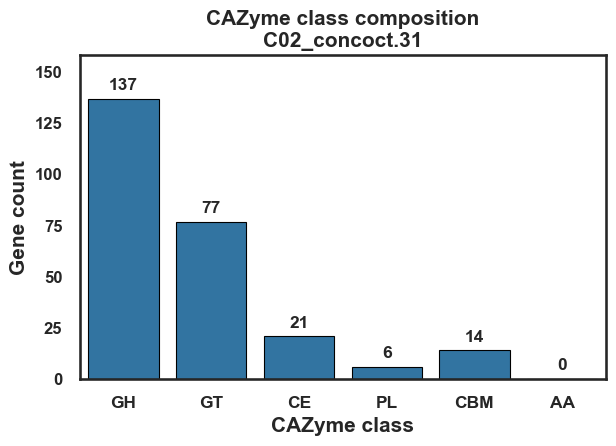

In [54]:
# =========================
# CAZyme class composition
# =========================
class_counts = (
    fam_df
    .dropna(subset=["Class"])
    .groupby("Class")
    .size()
    .reindex(CAZYME_CLASSES)
    .fillna(0)
    .astype(int)
    .reset_index(name="Count")
)

plt.figure(figsize=(6.5, 4.8))

ax = sns.barplot(
    data=class_counts,
    x="Class",
    y="Count",
    edgecolor="black",
    linewidth=0.8
)

for p in ax.patches:
    h = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        h + max(class_counts["Count"]) * 0.02,
        f"{int(h)}",
        ha="center",
        va="bottom",
        fontsize=12.5,
        fontweight="bold"
    )

plt.xlabel("CAZyme class", fontsize=15, fontweight="bold")
plt.ylabel("Gene count", fontsize=15, fontweight="bold")
plt.title(f"CAZyme class composition\n{MAG_NAME}", fontsize=15, fontweight="bold")

y0, y1 = ax.get_ylim()
plt.ylim(y0,y1*1.1)

plt.xticks(fontsize=12.5, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.tight_layout()

plt.savefig(os.path.join(OUT_DIR, "CAZyme_class_composition.png"), dpi=500, bbox_inches="tight")
plt.show()

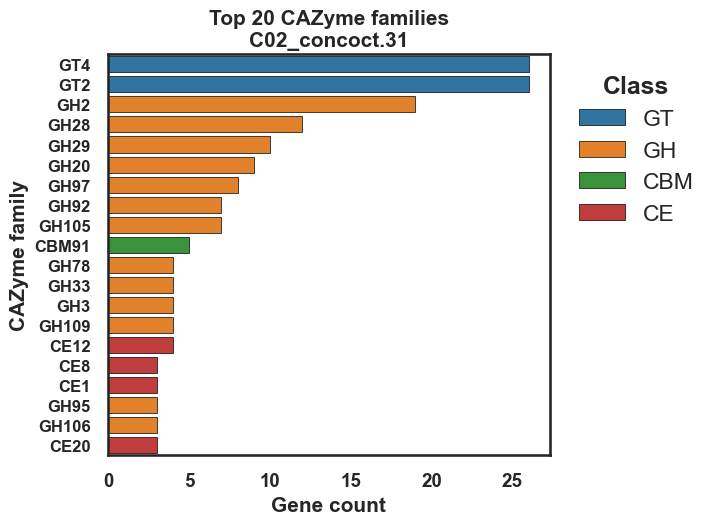

In [60]:
# =========================
# Top CAZyme families
# =========================
TOP_N = 20

family_counts = (
    fam_df
    .groupby(["Family", "Class"])
    .size()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
    .head(TOP_N)
)

plt.figure(figsize=(7.5, max(5, TOP_N * 0.28)))

ax = sns.barplot(
    data=family_counts,
    y="Family",
    x="Count",
    hue="Class",
    dodge=False,
    edgecolor="black",
    linewidth=0.5
)

plt.xlabel("Gene count", fontsize=15, fontweight="bold")
plt.ylabel("CAZyme family", fontsize=15, fontweight="bold")
plt.title(f"Top {TOP_N} CAZyme families\n{MAG_NAME}", fontsize=15, fontweight="bold")

plt.xticks(fontsize=13.5, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

leg = ax.legend(title="Class", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
leg.get_title().set_fontweight("bold")

plt.tight_layout()

plt.savefig(os.path.join(OUT_DIR, "top_CAZyme_families.png"), dpi=500, bbox_inches="tight")
plt.show()

In [61]:
def read_cgc_standard(path):
    if not os.path.exists(path):
        print(f"cgc_standard.out not found: {path}")
        return None

    rows = []

    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()

            # 빈 줄 / comment 제거
            if not line or line.startswith("#"):
                continue

            # tab 우선 분리
            parts = line.split("\t")

            # tab으로 안 나뉘면 공백 기준 분리
            if len(parts) < 8:
                parts = re.split(r"\s+", line)

            # 8개 미만이면 설명줄로 보고 skip
            if len(parts) < 8:
                continue

            # header line skip
            first = parts[0].lower()
            if first in ["cgc#", "cgcid", "cgc_id", "cgc"]:
                continue

            # 8번째 이후 column은 annotation으로 합침
            cgc_id = parts[0]
            gene_type = parts[1]
            contig_id = parts[2]
            gene_id = parts[3]
            start = parts[4]
            end = parts[5]
            strand = parts[6]
            annotation = ";".join(parts[7:])

            rows.append([
                cgc_id,
                gene_type,
                contig_id,
                gene_id,
                start,
                end,
                strand,
                annotation
            ])

    tmp = pd.DataFrame(
        rows,
        columns=[
            "CGC_ID",
            "Type",
            "Contig_ID",
            "Gene_ID",
            "Start",
            "End",
            "Strand",
            "Annotation"
        ]
    )

    if tmp.empty:
        raise ValueError("No valid CGC rows were parsed. Check cgc_standard.out format.")

    tmp["Start"] = pd.to_numeric(tmp["Start"], errors="coerce")
    tmp["End"] = pd.to_numeric(tmp["End"], errors="coerce")

    return tmp


cgc_df = read_cgc_standard(CGC_FILE)

if cgc_df is not None:
    print(cgc_df.head())
    print("Number of CGCs:", cgc_df["CGC_ID"].nunique())

  CGC_ID    Type Contig_ID       Gene_ID  Start    End Strand  Annotation
0   CGC1  CAZyme  contig_1  IIJEOF_00004   3001   5073      -        PL27
1   CGC1     STP  contig_1  IIJEOF_00005   5691   7055      -        PALP
2   CGC1      TC  contig_1  IIJEOF_00006   7232   9079      +  2.A.38.4.1
3   CGC1      TC  contig_1  IIJEOF_00007   9082   9768      +  2.A.38.4.3
4   CGC1      TC  contig_1  IIJEOF_00013  15275  18628      -  1.B.14.6.1
Number of CGCs: 4


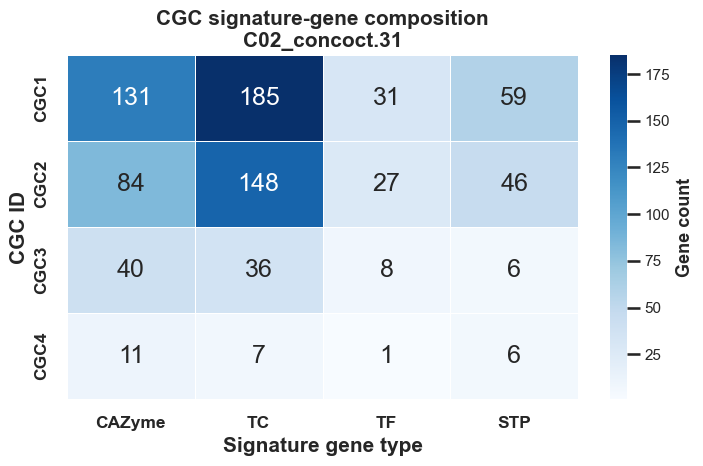

In [65]:
if cgc_df is not None:
    # Normalize gene type labels
    cgc_df["Type_clean"] = cgc_df["Type"].str.strip()

    # Keep common dbCAN signature gene types
    type_order = ["CAZyme", "TC", "TF", "STP"]
    
    cgc_type_counts = (
        cgc_df
        .groupby(["CGC_ID", "Type_clean"])
        .size()
        .unstack(fill_value=0)
        )
    
    # null column 제거
    cgc_type_counts = cgc_type_counts.drop(columns=["null"], errors="ignore")
    
    # ensure columns exist
    for t in type_order:
        if t not in cgc_type_counts.columns:
            cgc_type_counts[t] = 0
    
    cgc_type_counts = cgc_type_counts[type_order]
    
    # Sort CGCs by CAZyme count, then total genes
    cgc_type_counts["Total"] = cgc_type_counts.sum(axis=1)
    cgc_type_counts = cgc_type_counts.sort_values(["CAZyme", "Total"], ascending=False)
    plot_df = cgc_type_counts.drop(columns=["Total"])

    # If too many CGCs, show top 30
    MAX_CGC = 30
    plot_df_top = plot_df.head(MAX_CGC)

    plt.figure(figsize=(7.5, max(5, plot_df_top.shape[0] * 0.32)))

    ax = sns.heatmap(
        plot_df_top,
        cmap="Blues",
        annot=True,
        fmt="d",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Gene count"}
    )

    plt.xlabel("Signature gene type", fontsize=15, fontweight="bold")
    plt.ylabel("CGC ID", fontsize=15, fontweight="bold")
    plt.title(f"CGC signature-gene composition\n{MAG_NAME}", fontsize=15, fontweight="bold")

    plt.xticks(fontsize=12.5, fontweight='bold')
    plt.yticks(fontsize=12.5, fontweight='bold')
    
    cbar = ax.collections[0].colorbar
    cbar.ax.set_ylabel("Gene count", fontsize=13, fontweight="bold")
    cbar.ax.tick_params(labelsize=11)

    plt.tight_layout()

    plt.savefig(os.path.join(OUT_DIR, "CGC_signature_gene_heatmap.png"), dpi=500, bbox_inches="tight")
    plt.show()

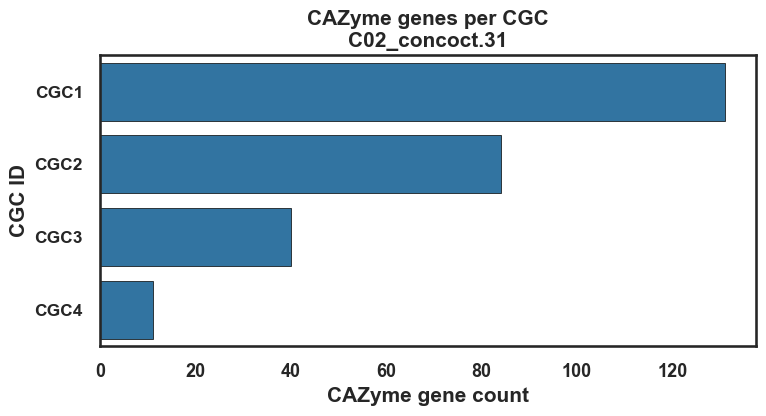

In [70]:
if cgc_df is not None:
    cgc_cazy_counts = (
        cgc_df[cgc_df["Type_clean"] == "CAZyme"]
        .groupby("CGC_ID")
        .size()
        .reset_index(name="CAZyme_gene_count")
        .sort_values("CAZyme_gene_count", ascending=False)
    )

    MAX_CGC = 30
    cgc_cazy_top = cgc_cazy_counts.head(MAX_CGC)

    plt.figure(figsize=(8, max(4.5, len(cgc_cazy_top) * 0.28)))

    ax = sns.barplot(
        data=cgc_cazy_top,
        y="CGC_ID",
        x="CAZyme_gene_count",
        edgecolor="black",
        linewidth=0.5
    )

    plt.xlabel("CAZyme gene count", fontsize=15, fontweight="bold")
    plt.ylabel("CGC ID", fontsize=15, fontweight="bold")
    plt.title(f"CAZyme genes per CGC\n{MAG_NAME}", fontsize=15, fontweight="bold")

    plt.xticks(fontsize=13, fontweight='bold')
    plt.yticks(fontsize=12.5, fontweight='bold')
    
    plt.tight_layout()

    plt.savefig(os.path.join(OUT_DIR, "CGC_CAZyme_gene_count_barplot.png"), dpi=500, bbox_inches="tight")
    plt.show()

In [71]:
def read_substrate(path):
    if not os.path.exists(path):
        print(f"substrate.out not found: {path}")
        return None

    sub = pd.read_csv(path, sep="\t", dtype=str)
    sub.columns = [c.strip() for c in sub.columns]

    print("substrate.out columns:")
    print(sub.columns.tolist())

    return sub


substrate_df = read_substrate(SUBSTRATE_FILE)

substrate.out columns:
['#cgcid', 'PULID', 'dbCAN-PUL substrate', 'bitscore', 'signature pairs', 'dbCAN-sub substrate', 'dbCAN-sub substrate score']


Using substrate column: dbCAN-PUL substrate


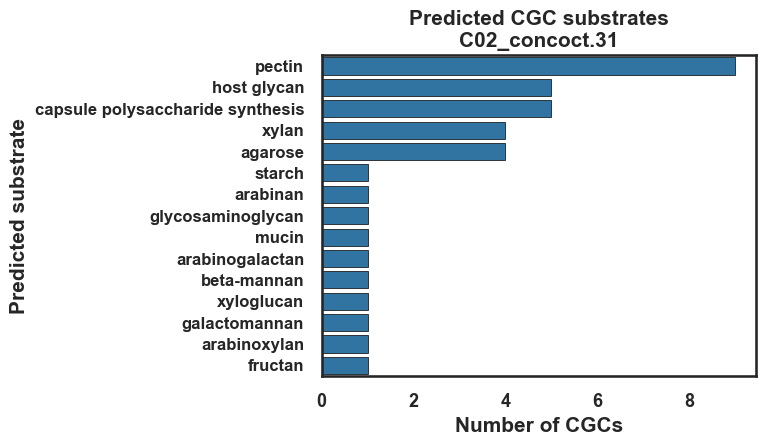

In [76]:
if substrate_df is not None:
    # Candidate substrate columns
    pul_candidates = [
        "Substrate of the hit PUL",
        "PUL_Substrate",
        "dbCAN-PUL substrate",
        "Substrate"
    ]

    voting_candidates = [
        "Substrate predicted by majority voting of CAZymes in CGC",
        "Majority_voting_substrate",
        "dbCAN-sub substrate"
    ]

    substrate_col = None

    # Prefer PUL-based substrate if present
    for c in pul_candidates:
        if c in substrate_df.columns:
            substrate_col = c
            break

    # fallback to voting substrate
    if substrate_col is None:
        for c in voting_candidates:
            if c in substrate_df.columns:
                substrate_col = c
                break

    # fallback: find any column containing substrate
    if substrate_col is None:
        candidates = [c for c in substrate_df.columns if "substrate" in c.lower()]
        if len(candidates) > 0:
            substrate_col = candidates[0]

    if substrate_col is None:
        raise ValueError("No substrate-like column found in substrate.out. Check printed columns.")

    print(f"Using substrate column: {substrate_col}")

    sub_plot = substrate_df.copy()
    sub_plot[substrate_col] = sub_plot[substrate_col].replace(["", "-", "None", "nan", "NaN"], np.nan)
    sub_plot = sub_plot.dropna(subset=[substrate_col])

    # If multiple substrates are separated by semicolon/comma, split
    rows = []
    for _, row in sub_plot.iterrows():
        vals = re.split(r";|,", str(row[substrate_col]))
        for v in vals:
            v = v.strip()
            if v and v.lower() not in ["nan", "none", "-"]:
                rows.append(v)

    substrate_counts = (
        pd.Series(rows)
        .value_counts()
        .reset_index()
    )
    substrate_counts.columns = ["Predicted_substrate", "CGC_count"]

    TOP_N = 20
    substrate_counts_top = substrate_counts.head(TOP_N)

    plt.figure(figsize=(8, max(4.5, len(substrate_counts_top) * 0.32)))

    ax = sns.barplot(
        data=substrate_counts_top,
        y="Predicted_substrate",
        x="CGC_count",
        edgecolor="black",
        linewidth=0.5
    )

    plt.xlabel("Number of CGCs", fontsize=15, fontweight="bold")
    plt.ylabel("Predicted substrate", fontsize=15, fontweight="bold")
    plt.title(f"Predicted CGC substrates\n{MAG_NAME}", fontsize=15, fontweight="bold")

    plt.xticks(fontsize=13, fontweight='bold')
    plt.yticks(fontsize=12, fontweight='bold')
    
    plt.tight_layout()

    plt.savefig(os.path.join(OUT_DIR, "predicted_CGC_substrates.png"), dpi=500, bbox_inches="tight")
    plt.show()

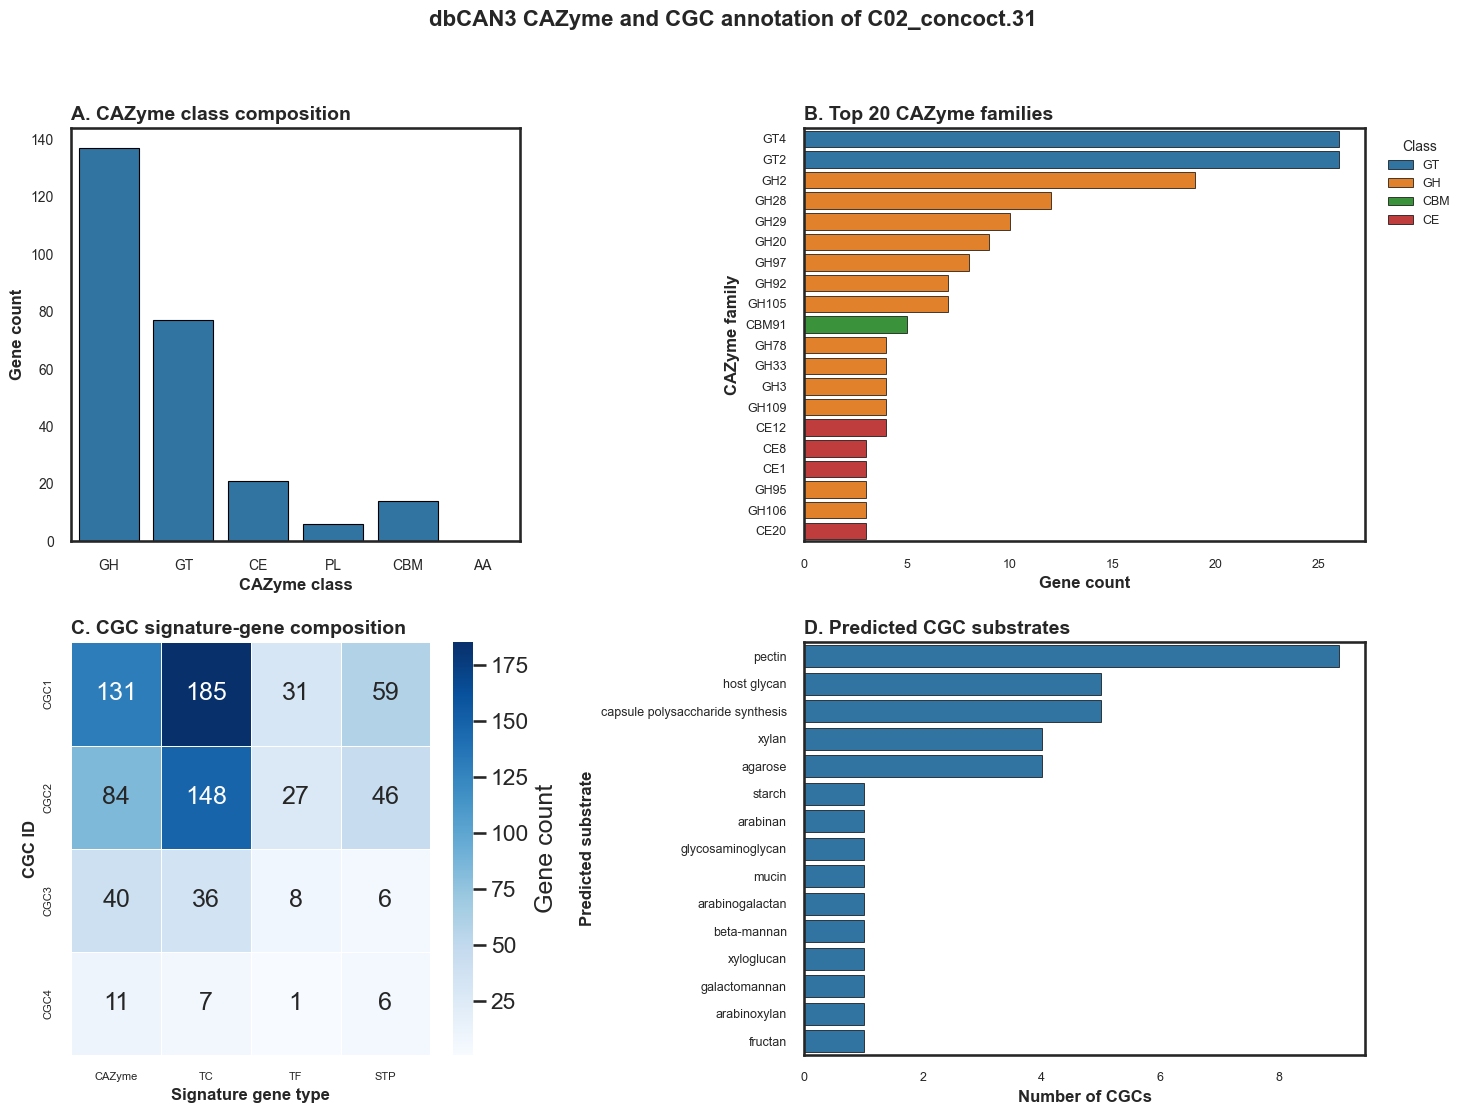

In [77]:
# =========================
# Combined Figure 40
# =========================
fig, axes = plt.subplots(
    2, 2,
    figsize=(15, 11),
    gridspec_kw={"width_ratios": [1, 1.25], "height_ratios": [1, 1]}
)

# -------------------------
# A. Class composition
# -------------------------
ax = axes[0, 0]
sns.barplot(
    data=class_counts,
    x="Class",
    y="Count",
    edgecolor="black",
    linewidth=0.8,
    ax=ax
)
ax.set_title("A. CAZyme class composition", fontsize=14, fontweight="bold", loc="left")
ax.set_xlabel("CAZyme class", fontsize=12, fontweight="bold")
ax.set_ylabel("Gene count", fontsize=12, fontweight="bold")
ax.tick_params(axis="both", labelsize=10)

# -------------------------
# B. Top families
# -------------------------
ax = axes[0, 1]
sns.barplot(
    data=family_counts,
    y="Family",
    x="Count",
    hue="Class",
    dodge=False,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)
ax.set_title(f"B. Top {TOP_N} CAZyme families", fontsize=14, fontweight="bold", loc="left")
ax.set_xlabel("Gene count", fontsize=12, fontweight="bold")
ax.set_ylabel("CAZyme family", fontsize=12, fontweight="bold")
ax.tick_params(axis="both", labelsize=9)
ax.legend(title="Class", frameon=False, fontsize=9, title_fontsize=10, bbox_to_anchor=(1.02, 1), loc="upper left")

# -------------------------
# C. CGC signature-gene composition
# -------------------------
ax = axes[1, 0]
if cgc_df is not None:
    heat_data = plot_df_top.copy()
    sns.heatmap(
        heat_data,
        cmap="Blues",
        annot=True,
        fmt="d",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Gene count"},
        ax=ax
    )
    ax.set_title("C. CGC signature-gene composition", fontsize=14, fontweight="bold", loc="left")
    ax.set_xlabel("Signature gene type", fontsize=12, fontweight="bold")
    ax.set_ylabel("CGC ID", fontsize=12, fontweight="bold")
    ax.tick_params(axis="both", labelsize=8)
else:
    ax.axis("off")
    ax.text(0.5, 0.5, "No cgc_standard.out", ha="center", va="center")

# -------------------------
# D. Predicted substrates
# -------------------------
ax = axes[1, 1]
if substrate_df is not None and "substrate_counts_top" in globals() and len(substrate_counts_top) > 0:
    sns.barplot(
        data=substrate_counts_top,
        y="Predicted_substrate",
        x="CGC_count",
        edgecolor="black",
        linewidth=0.5,
        ax=ax
    )
    ax.set_title("D. Predicted CGC substrates", fontsize=14, fontweight="bold", loc="left")
    ax.set_xlabel("Number of CGCs", fontsize=12, fontweight="bold")
    ax.set_ylabel("Predicted substrate", fontsize=12, fontweight="bold")
    ax.tick_params(axis="both", labelsize=9)
else:
    ax.axis("off")
    ax.text(0.5, 0.5, "No substrate prediction", ha="center", va="center")

plt.suptitle(
    f"dbCAN3 CAZyme and CGC annotation of {MAG_NAME}",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

plt.savefig(os.path.join(OUT_DIR, "dbCAN3_combined_panel.png"), dpi=500, bbox_inches="tight")
plt.show()